
# STATS 608 Project Wrap-Up: Posterior Sampling in Sparse Gaussian DAGs

This notebook wraps up the project with:
- the enhanced experiment pipeline,
- the precomputed experiment outputs,
- the figures supporting the main conclusions,
- short explanations of the measures used,
- a compact interpretation of what the results mean.

The original project used a sparse linear Gaussian DAG with exact Gaussian posterior ground truth, plus single-site Gibbs, layer/block Gibbs, and random-walk Metropolis-Hastings. The proposal explicitly framed the goal as a **decision guide** for which sampler works best under different graph structures and conditioning regimes.  



## What changed in the enhanced version

To make the project more meaningful, I added:

1. **Posterior-geometry diagnostics**  
   posterior condition number, posterior correlation, precision-graph density.

2. **Theory-guided Gibbs diagnostics**  
   the **Gaussian Gibbs spectral radius** computed from the exact posterior precision matrix.

3. **Better block constructions**  
   not only layer/depth blocks, but also:
   - topological-window blocks,
   - random blocks,
   - posterior-precision BFS blocks.

4. **A DAG-native non-MCMC baseline**  
   **likelihood weighting / sequential importance sampling (SIS)**.

5. **A gradient-informed MH baseline**  
   **diagonal-preconditioned MALA**.

6. **Variance reduction inside block Gibbs**  
   **Rao-Blackwellized** estimates of posterior means and variances.

7. **A straightforward next experiment**  
   a **block-size sweep** to see whether larger blocks help and when.


In [1]:

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

sys.path.insert(0, "/mnt/data")

import enhanced_pipeline as ep

base = Path("/mnt/data/stats608_enhanced")
fig_dir = base / "figures"

primary = pd.read_csv(base / "primary_results.csv")
stress = pd.read_csv(base / "stress_results.csv")
block_sweep = pd.read_csv(base / "block_size_sweep.csv")

print("Primary rows:", primary.shape[0])
print("Stress rows:", stress.shape[0])
print("Block sweep rows:", block_sweep.shape[0])


Primary rows: 576
Stress rows: 288
Block sweep rows: 90



## Measures used and what they mean

### 1. ESS
For an MCMC chain, the effective sample size is estimated coordinatewise using the standard autocorrelation formula
\[
\text{ESS} \approx \frac{n}{1 + 2\sum_{k\ge 1}\rho_k}.
\]
Larger ESS means less serial dependence and better mixing.

### 2. ESS / second
\[
\text{ESS/sec} = \frac{\text{ESS}}{\text{runtime in seconds}}.
\]
This is the main **efficiency** measure for MCMC: it combines statistical mixing and computational cost.

### 3. Weighted ESS fraction for SIS
For importance weights \(\tilde w_i\) normalized to sum to 1,
\[
\text{ESS}_w = \frac{1}{\sum_i \tilde w_i^2}.
\]
I also report
\[
\text{weighted ESS fraction} = \frac{\text{ESS}_w}{N}.
\]
If this is tiny, the weighted sample is effectively collapsing onto very few particles.

### 4. Mean RMSE
If \(\hat\mu\) is the Monte Carlo estimate of the posterior mean and \(\mu\) is the exact Gaussian truth,
\[
\mathrm{RMSE}_{\text{mean}} = \sqrt{\frac{1}{d}\sum_{j=1}^d (\hat\mu_j - \mu_j)^2 }.
\]
Smaller is better.

### 5. Variance RMSE
This compares the posterior variances:
\[
\mathrm{RMSE}_{\text{var}} = \sqrt{\frac{1}{d}\sum_{j=1}^d (\hat\Sigma_{jj} - \Sigma_{jj})^2 }.
\]

### 6. Covariance Frobenius error
\[
\|\hat\Sigma - \Sigma\|_F.
\]
This is a global covariance-matrix error.

### 7. Acceptance rate
For MH-type samplers only.  
Very low acceptance usually means proposals are too aggressive; very high acceptance can mean overly conservative local moves.

### 8. Posterior condition number
A large condition number means the posterior is geometrically anisotropic, which usually hurts generic random-walk proposals.

### 9. Gibbs spectral radius
For Gaussian Gibbs/block-Gibbs, the deterministic error-propagation map has a spectral radius \(\rho\).  
Values closer to 1 indicate slower geometric contraction, hence worse mixing.

### 10. Within-block precision mass / block cut ratio
These measure how much posterior precision coupling is captured **inside** blocks versus **across** blocks.
- high within-block precision mass = the blocks align well with posterior dependence,
- high cut ratio = much of the dependence is split across blocks.

### 11. Rao-Blackwellized RMSE
Instead of estimating means/variances from raw samples only, I use conditional Gaussian expectations inside each Gibbs block when available.  
This should reduce Monte Carlo variance.


## Primary experiment: broad comparison

In [2]:

primary_summary = (
    primary.groupby("method")
    .agg(
        runs=("method", "size"),
        ess_per_second=("ess_per_second", "mean"),
        ess_mean=("ess_mean", "mean"),
        runtime_seconds=("runtime_seconds", "mean"),
        mean_rmse=("mean_rmse", "mean"),
        variance_rmse=("variance_rmse", "mean"),
        covariance_frobenius_error=("covariance_frobenius_error", "mean"),
        acceptance_rate=("acceptance_rate", "mean"),
        weighted_ess_fraction=("weighted_ess_fraction", "mean"),
    )
    .sort_values("mean_rmse")
)
display(primary_summary.round(4))


,runs,ess_per_second,ess_mean,runtime_seconds,mean_rmse,variance_rmse,covariance_frobenius_error,acceptance_rate,weighted_ess_fraction
method,,,,,,,,,
block_precision_bfs,72,9219.2886,373.5743,0.0443,0.0674,0.0937,1.7534,NaN,NaN
block_random,72,17963.1814,319.4892,0.0185,0.0749,0.1045,1.9052,NaN,NaN
block_depth,72,11690.7951,300.0351,0.0291,0.0766,0.1183,2.1853,NaN,NaN
block_topological,72,17862.3197,318.6532,0.0184,0.0793,0.1002,1.9069,NaN,NaN
single_site_gibbs,72,5873.1103,296.8082,0.0535,0.0808,0.1081,2.0386,NaN,NaN
likelihood_weighting_sis,72,177547.8492,269.1936,0.0015,0.1075,0.1636,3.0468,NaN,0.5384
mala_diag,72,1466.4133,30.2757,0.0208,0.2906,0.3427,5.6323,0.8888,NaN
rw_mh,72,1931.8952,10.0834,0.0053,0.5597,0.6616,9.2155,0.2582,NaN


### primary_ess_per_second.png

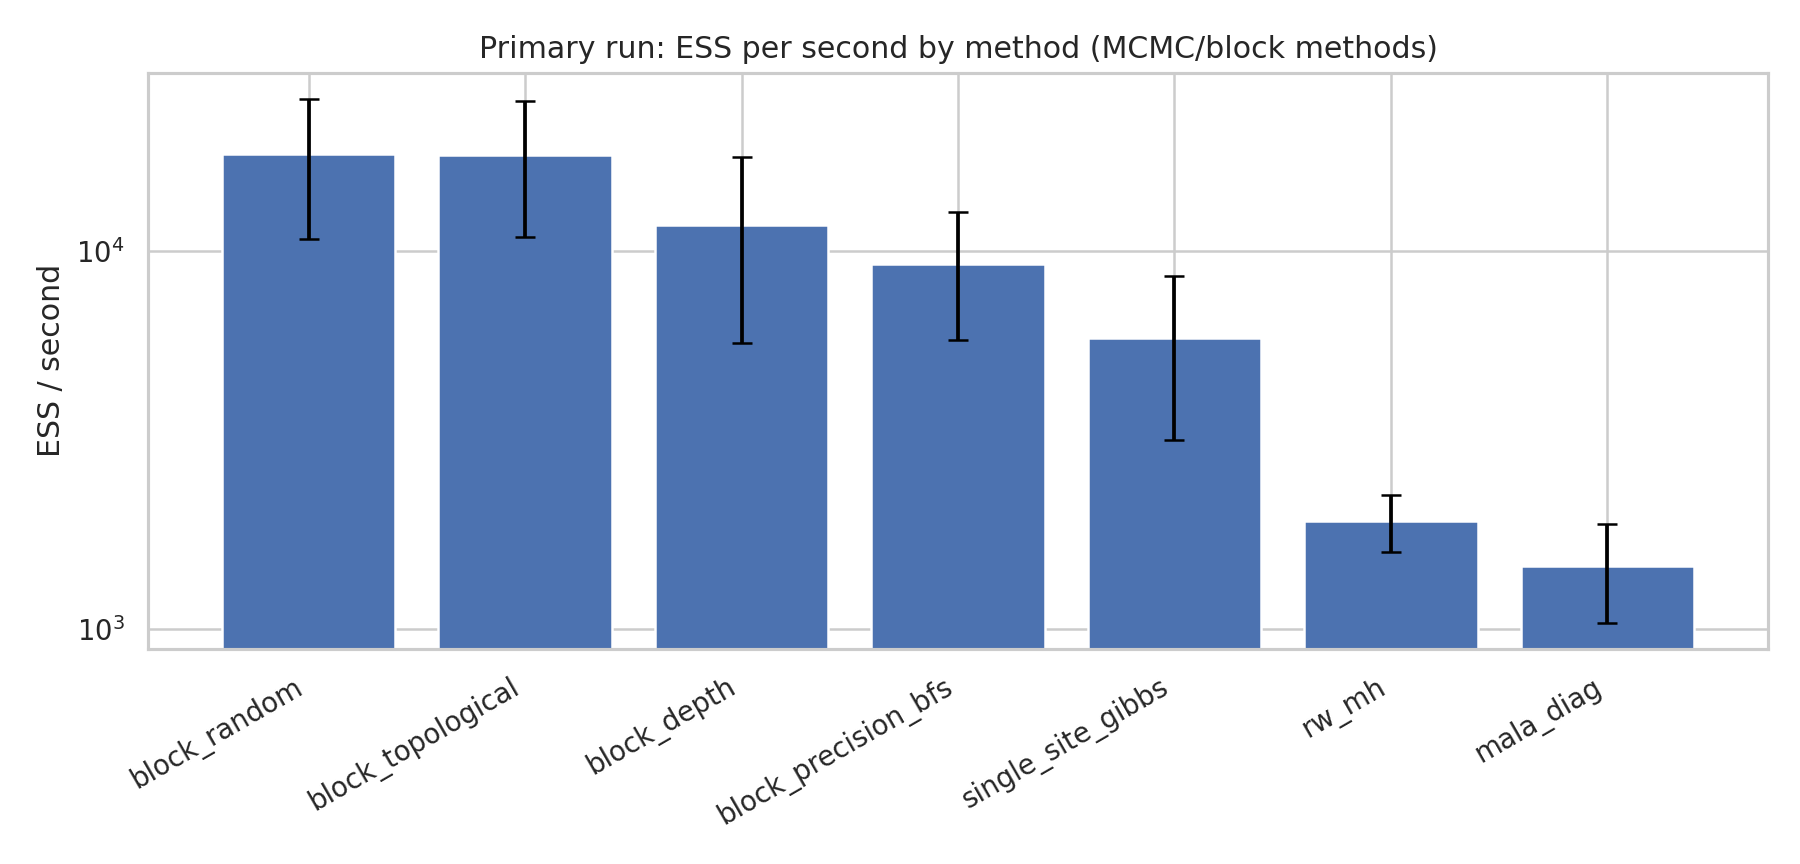

### primary_mean_rmse.png

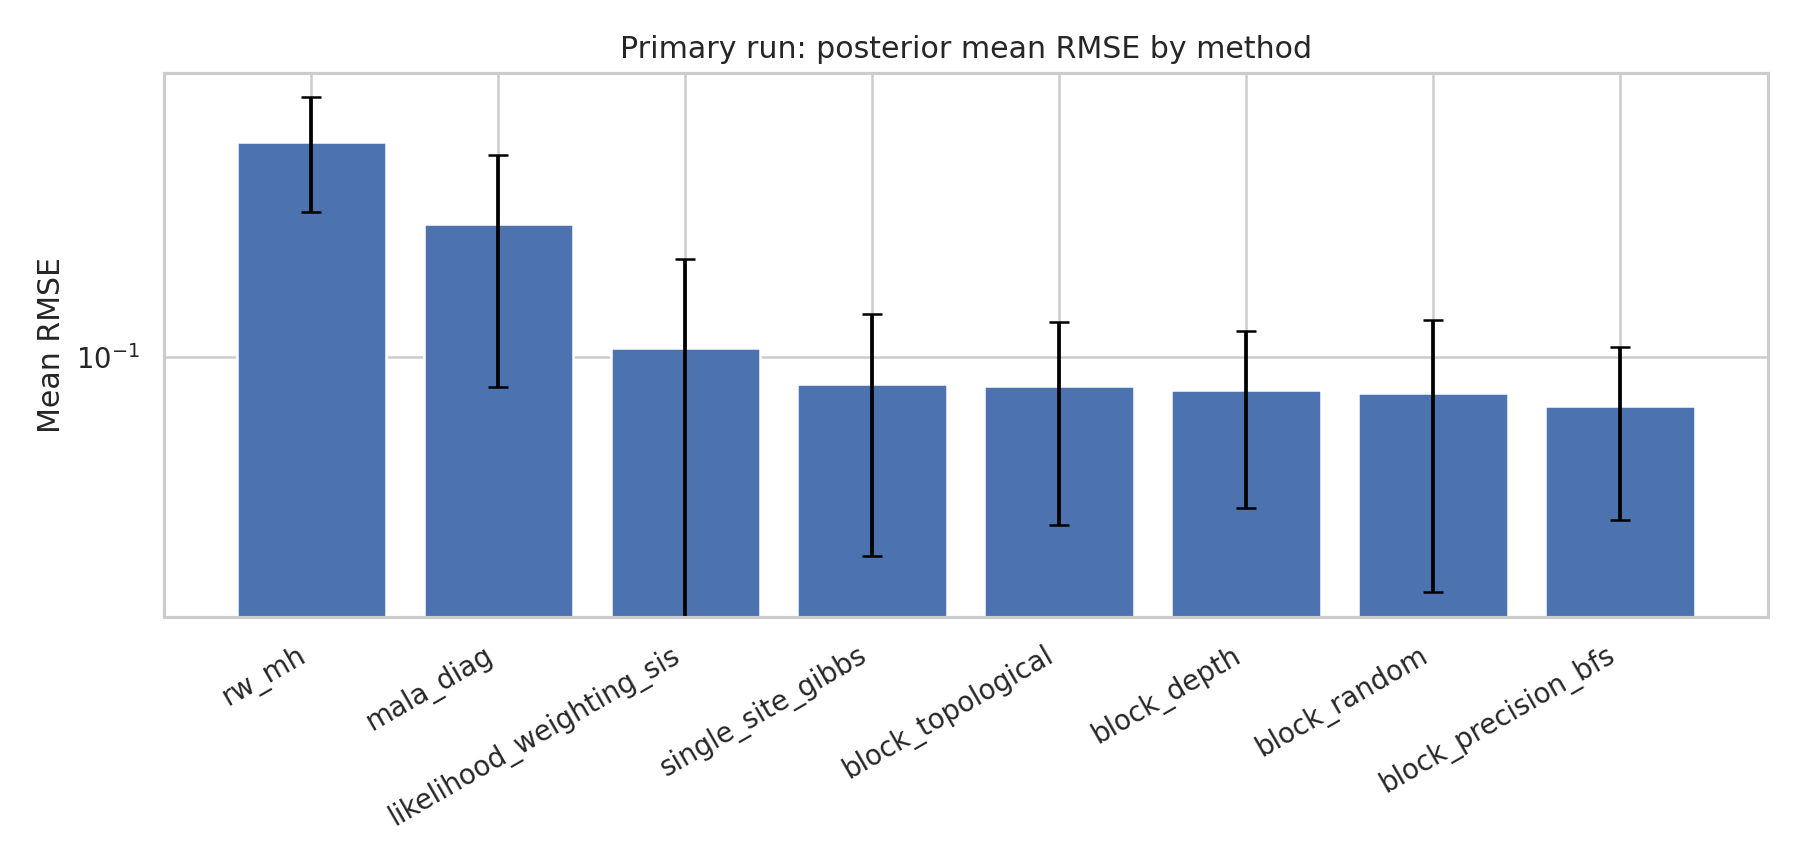

### primary_random_spectral_vs_ess.png

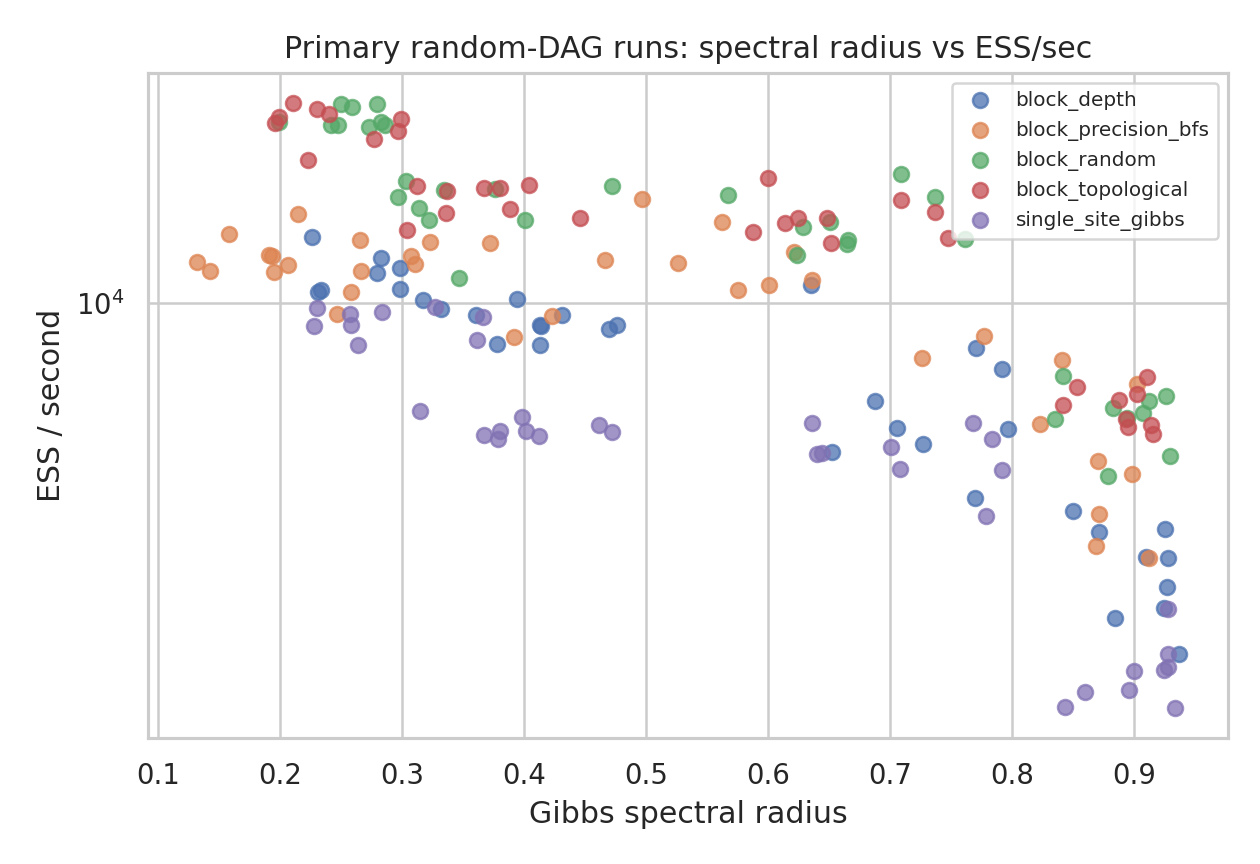

### primary_random_spectral_vs_rmse.png

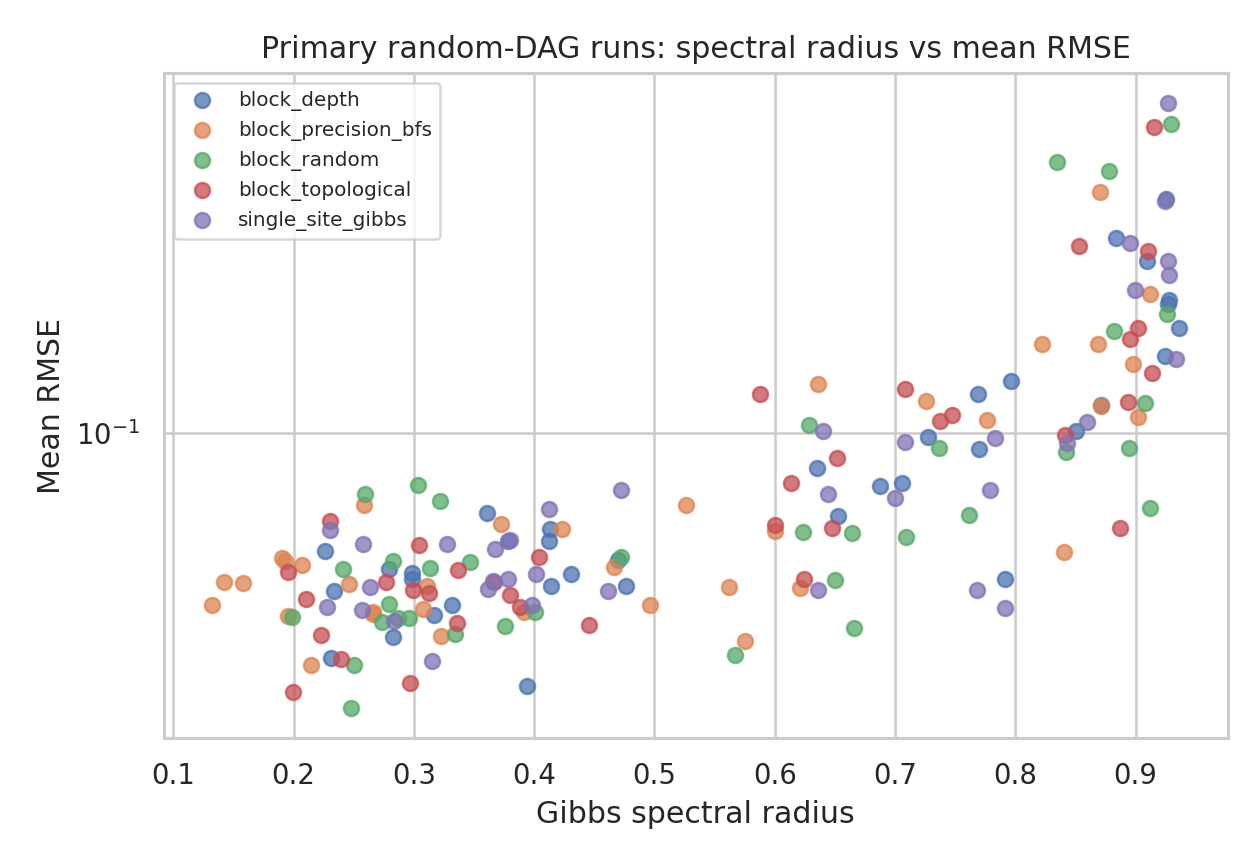

### primary_random_block_quality_vs_ess.png

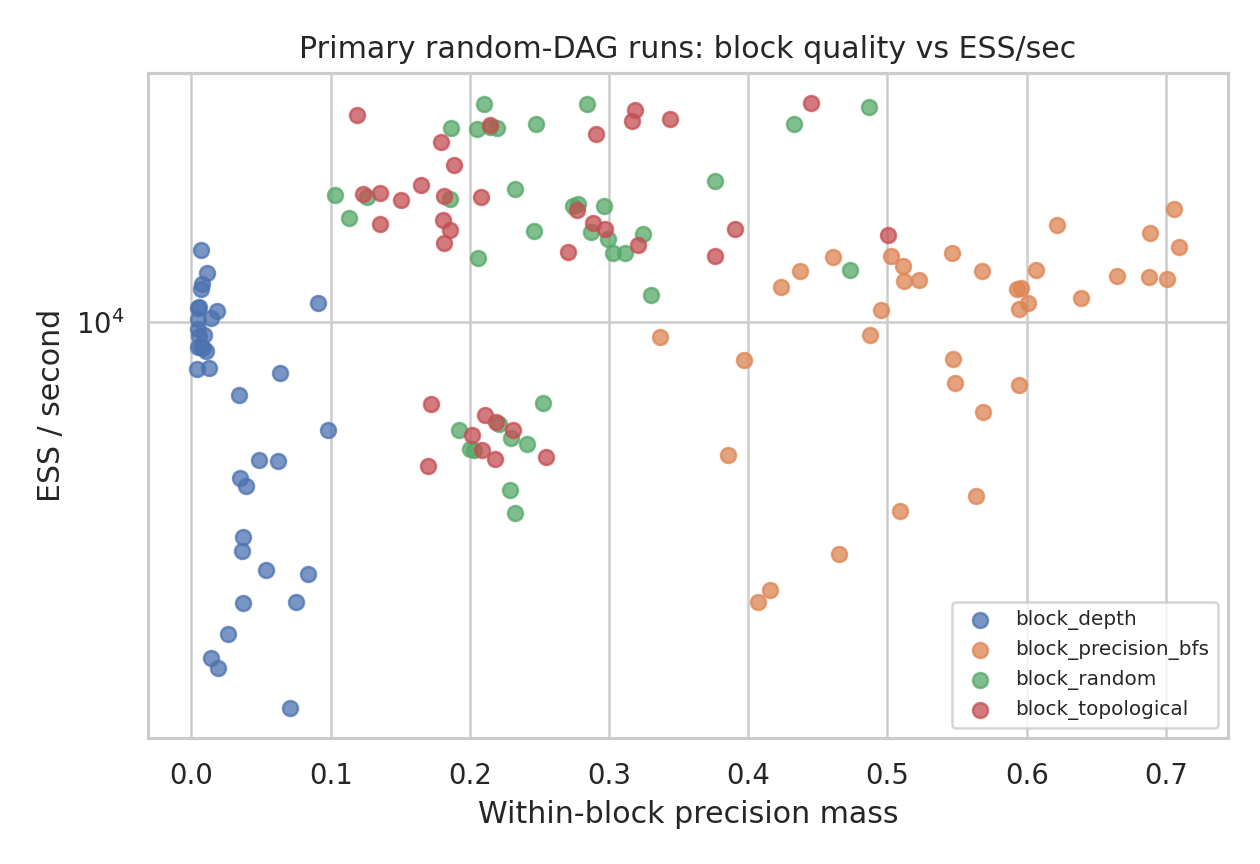

### primary_rb_improvement.png

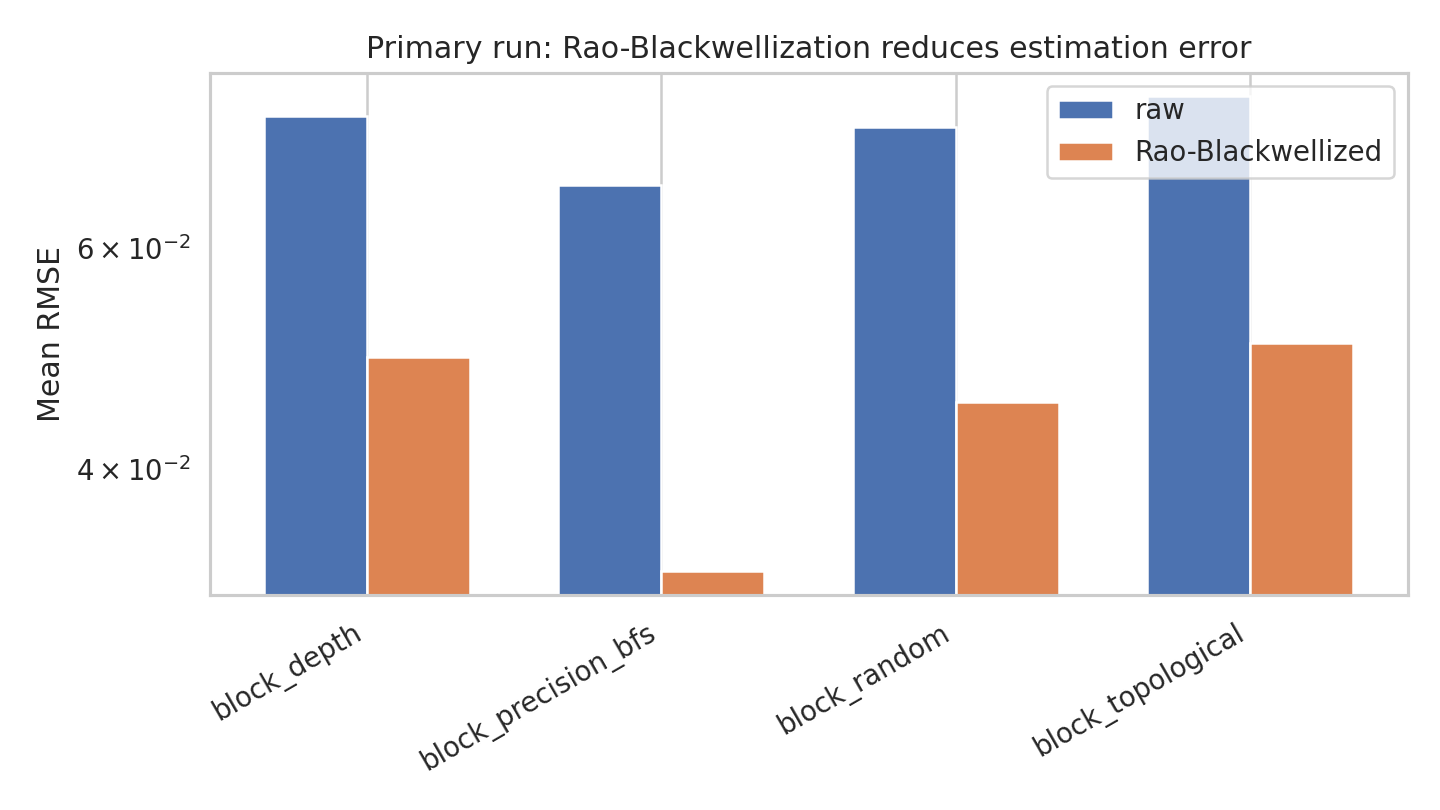

In [3]:

for fname in [
    "primary_ess_per_second.png",
    "primary_mean_rmse.png",
    "primary_random_spectral_vs_ess.png",
    "primary_random_spectral_vs_rmse.png",
    "primary_random_block_quality_vs_ess.png",
    "primary_rb_improvement.png",
]:
    display(Markdown(f"### {fname}"))
    display(Image(filename=str(fig_dir / fname)))


In [4]:

def spearman(x, y):
    xs = pd.Series(x).rank().to_numpy()
    ys = pd.Series(y).rank().to_numpy()
    return float(np.corrcoef(xs, ys)[0, 1])

gibbs_primary_random = primary[
    (primary["graph_type"] == "random_sparse") &
    (primary["gibbs_spectral_radius"].notna())
].copy()

block_primary_random = primary[
    (primary["graph_type"] == "random_sparse") &
    (primary["method"].str.startswith("block_"))
].copy()

summary_random_blocks = (
    block_primary_random.groupby("method")[
        ["ess_per_second", "mean_rmse", "gibbs_spectral_radius",
         "block_within_precision_mass", "block_cut_ratio", "rb_mean_rmse"]
    ]
    .mean()
    .sort_values("mean_rmse")
)

display(Markdown("### Random-DAG block-method summary"))
display(summary_random_blocks.round(4))

display(Markdown("### Diagnostic correlations in primary random-DAG Gibbs/block-Gibbs runs"))
corr_table = pd.DataFrame(
    {
        "metric": [
            "spectral radius vs ESS/sec",
            "spectral radius vs mean RMSE",
            "within-block mass vs ESS/sec",
        ],
        "spearman": [
            spearman(gibbs_primary_random["gibbs_spectral_radius"], gibbs_primary_random["ess_per_second"]),
            spearman(gibbs_primary_random["gibbs_spectral_radius"], gibbs_primary_random["mean_rmse"]),
            spearman(gibbs_primary_random["block_within_precision_mass"], gibbs_primary_random["ess_per_second"]),
        ],
    }
)
display(corr_table.round(4))


### Random-DAG block-method summary

,ess_per_second,mean_rmse,gibbs_spectral_radius,block_within_precision_mass,block_cut_ratio,rb_mean_rmse
method,,,,,,
block_precision_bfs,10397.7607,0.0792,0.4880,0.5448,0.4552,0.0484
block_topological,15834.8504,0.0895,0.5382,0.2408,0.7592,0.0630
block_random,15779.4363,0.0897,0.5416,0.2570,0.7430,0.0623
block_depth,7264.4277,0.0926,0.5816,0.0298,0.9702,0.0653


### Diagnostic correlations in primary random-DAG Gibbs/block-Gibbs runs

,metric,spearman
0,spectral radius vs ESS/sec,-0.6913
1,spectral radius vs mean RMSE,0.7688
2,within-block mass vs ESS/sec,0.4679



## Interpretation of the primary run

The main pattern is:

- **single-site Gibbs is a solid baseline**;
- **topological** and **random blocks** are often the fastest in raw ESS/sec;
- **precision-BFS blocks** are usually the strongest statistically in **RMSE** and **Rao-Blackwellized RMSE**, because they better capture posterior dependence;
- **random-walk MH** and **MALA** are clearly weaker than Gibbs-type methods in this Gaussian posterior setting;
- **Rao-Blackwellization** reduces estimation error noticeably for the block methods.

The key theoretical signal is that, in random-DAG settings, a **larger Gibbs spectral radius** is associated with:
- lower ESS/sec,
- higher RMSE.

That is exactly the kind of “decision-guide” result the proposal wanted.


## Stress experiment: harder conditioning

In [5]:

stress_summary = (
    stress.groupby("method")
    .agg(
        runs=("method", "size"),
        ess_per_second=("ess_per_second", "mean"),
        ess_mean=("ess_mean", "mean"),
        runtime_seconds=("runtime_seconds", "mean"),
        mean_rmse=("mean_rmse", "mean"),
        weighted_ess_fraction=("weighted_ess_fraction", "mean"),
        acceptance_rate=("acceptance_rate", "mean"),
    )
    .sort_values("mean_rmse")
)
display(stress_summary.round(4))

stress_sis = (
    stress[stress["method"] == "likelihood_weighting_sis"]
    .groupby(["observed_fraction", "observation_strategy"])[["weighted_ess_fraction", "mean_rmse"]]
    .mean()
)
display(Markdown("### SIS in the stress run"))
display(stress_sis.round(4))


,runs,ess_per_second,ess_mean,runtime_seconds,mean_rmse,weighted_ess_fraction,acceptance_rate
method,,,,,,,
single_site_gibbs,36,2829.6488,194.8958,0.1359,0.1850,NaN,NaN
block_precision_bfs,36,7317.0965,248.9125,0.0502,0.2002,NaN,NaN
block_depth,36,2568.6445,198.5515,0.0930,0.2136,NaN,NaN
block_topological,36,9274.9930,238.1364,0.0349,0.2212,NaN,NaN
block_random,36,9406.8185,231.9278,0.0349,0.2550,NaN,NaN
mala_diag,36,792.7669,22.6253,0.0290,0.6846,NaN,0.8375
likelihood_weighting_sis,36,1105.0985,3.2615,0.0034,0.8758,0.0047,NaN
rw_mh,36,1285.7709,9.6701,0.0076,1.8422,NaN,0.1154


### SIS in the stress run

weighted_ess_fraction  mean_rmse
observed_fraction observation_strategy                                  
0.1               deep                                 0.0059     0.9173
                  uniform                              0.0082     1.0750
0.4               deep                                 0.0017     1.0822
                  uniform                              0.0042     1.0042
0.7               deep                                 0.0032     0.6104
                  uniform                              0.0047     0.5659

### stress_mean_rmse.png

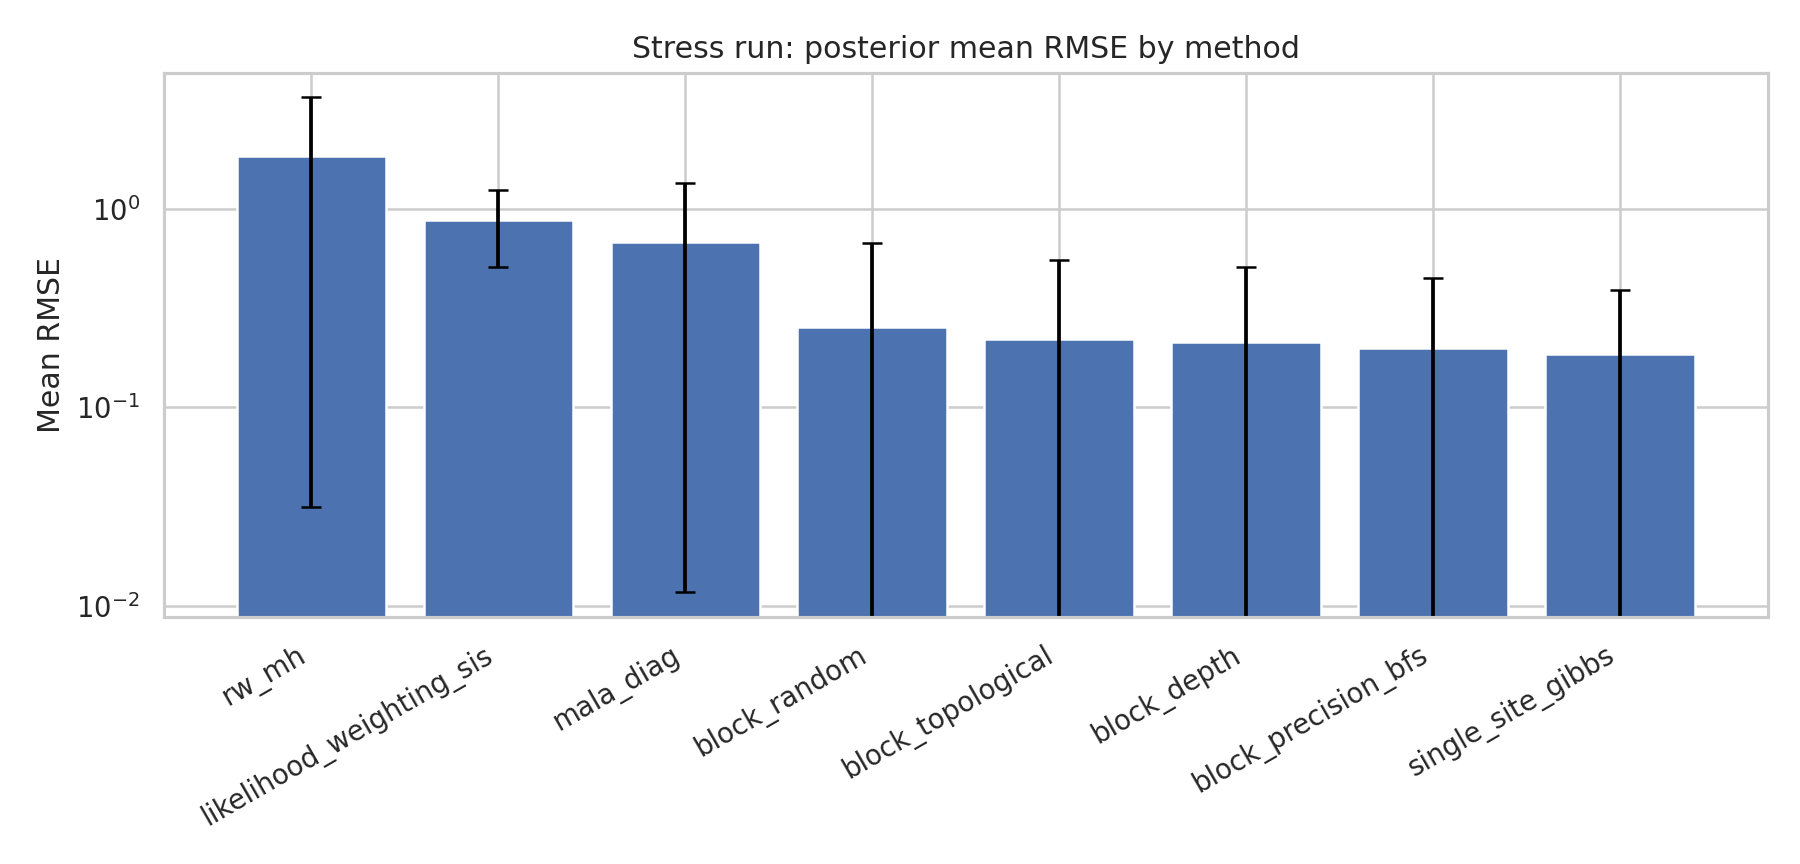

### stress_sis_weighted_ess_fraction.png

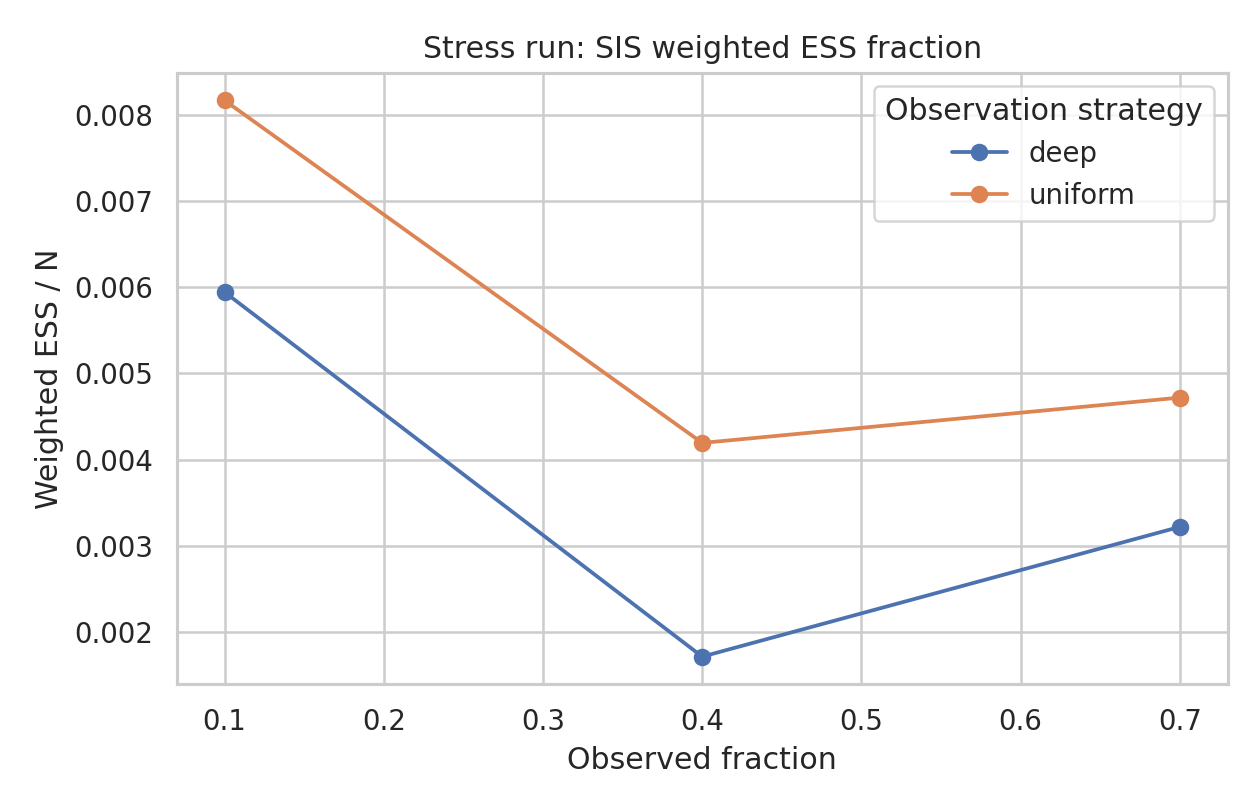

In [6]:

for fname in [
    "stress_mean_rmse.png",
    "stress_sis_weighted_ess_fraction.png",
]:
    display(Markdown(f"### {fname}"))
    display(Image(filename=str(fig_dir / fname)))


In [7]:

gibbs_stress = stress[stress["gibbs_spectral_radius"].notna()].copy()

stress_diag = pd.DataFrame(
    {
        "metric": [
            "spectral radius vs ESS/sec",
            "spectral radius vs mean RMSE",
            "within-block mass vs ESS/sec",
        ],
        "spearman": [
            spearman(gibbs_stress["gibbs_spectral_radius"], gibbs_stress["ess_per_second"]),
            spearman(gibbs_stress["gibbs_spectral_radius"], gibbs_stress["mean_rmse"]),
            spearman(gibbs_stress["block_within_precision_mass"], gibbs_stress["ess_per_second"]),
        ],
    }
)
display(stress_diag.round(4))


,metric,spearman
0,spectral radius vs ESS/sec,-0.9178
1,spectral radius vs mean RMSE,0.9295
2,within-block mass vs ESS/sec,0.5790



## Interpretation of the stress run

This is where the additional methods become most informative.

### SIS
The weighted ESS fraction collapses to values on the order of **0.001–0.01**.  
That means the ancestral-sampling-plus-weights strategy becomes effectively useless under hard evidence in these random DAGs.

### Gibbs / block Gibbs
They remain usable, but the choice of blocks matters more:
- layer/depth blocks deteriorate,
- precision-aware or topology-aware blocks are noticeably better.

### MH-type samplers
Random-walk MH becomes poor quickly, and MALA helps somewhat, but both remain weaker than the Gaussian conditional samplers.

### Theory-guided conclusion
In the stress run, the Gibbs spectral radius is very strongly linked to both:
- lower ESS/sec,
- higher RMSE.

So the project now says something deeper than “sampler A beat sampler B”: it identifies a structural diagnostic of difficulty.


## Straightforward next step that I already did: block-size sweep

In [8]:

block_summary = (
    block_sweep.groupby(["method", "block_size"])[
        ["ess_per_second", "mean_rmse", "rb_mean_rmse",
         "gibbs_spectral_radius", "block_within_precision_mass"]
    ]
    .mean()
    .reset_index()
)
display(block_summary.round(4))

best_by_method = (
    block_summary.sort_values(["method", "ess_per_second"], ascending=[True, False])
    .groupby("method")
    .head(1)
)
display(Markdown("### Best block size per method by ESS/sec"))
display(best_by_method.round(4))


,method,block_size,ess_per_second,mean_rmse,rb_mean_rmse,gibbs_spectral_radius,block_within_precision_mass
0,block_precision_bfs,2,1614.1519,0.0864,0.0715,0.8138,0.1814
1,block_precision_bfs,4,2746.9580,0.0659,0.0496,0.8180,0.2410
2,block_precision_bfs,8,4818.6033,0.0764,0.0571,0.7944,0.3455
3,block_precision_bfs,12,10214.9138,0.0645,0.0445,0.7453,0.4430
4,block_precision_bfs,16,8093.1884,0.0887,0.0666,0.7429,0.5473
5,block_random,2,1556.2060,0.1064,0.0916,0.8343,0.0232
6,block_random,4,3225.6181,0.0832,0.0688,0.8372,0.0825
7,block_random,8,5970.9650,0.0929,0.0765,0.8164,0.2077
8,block_random,12,10636.1141,0.0605,0.0442,0.7953,0.3000
9,block_random,16,11319.2021,0.0804,0.0604,0.7867,0.3617


### Best block size per method by ESS/sec

,method,block_size,ess_per_second,mean_rmse,rb_mean_rmse,gibbs_spectral_radius,block_within_precision_mass
3,block_precision_bfs,12,10214.9138,0.0645,0.0445,0.7453,0.4430
9,block_random,16,11319.2021,0.0804,0.0604,0.7867,0.3617
14,block_topological,16,12170.5121,0.0711,0.0536,0.7529,0.4992


### block_sweep_ess_per_second.png

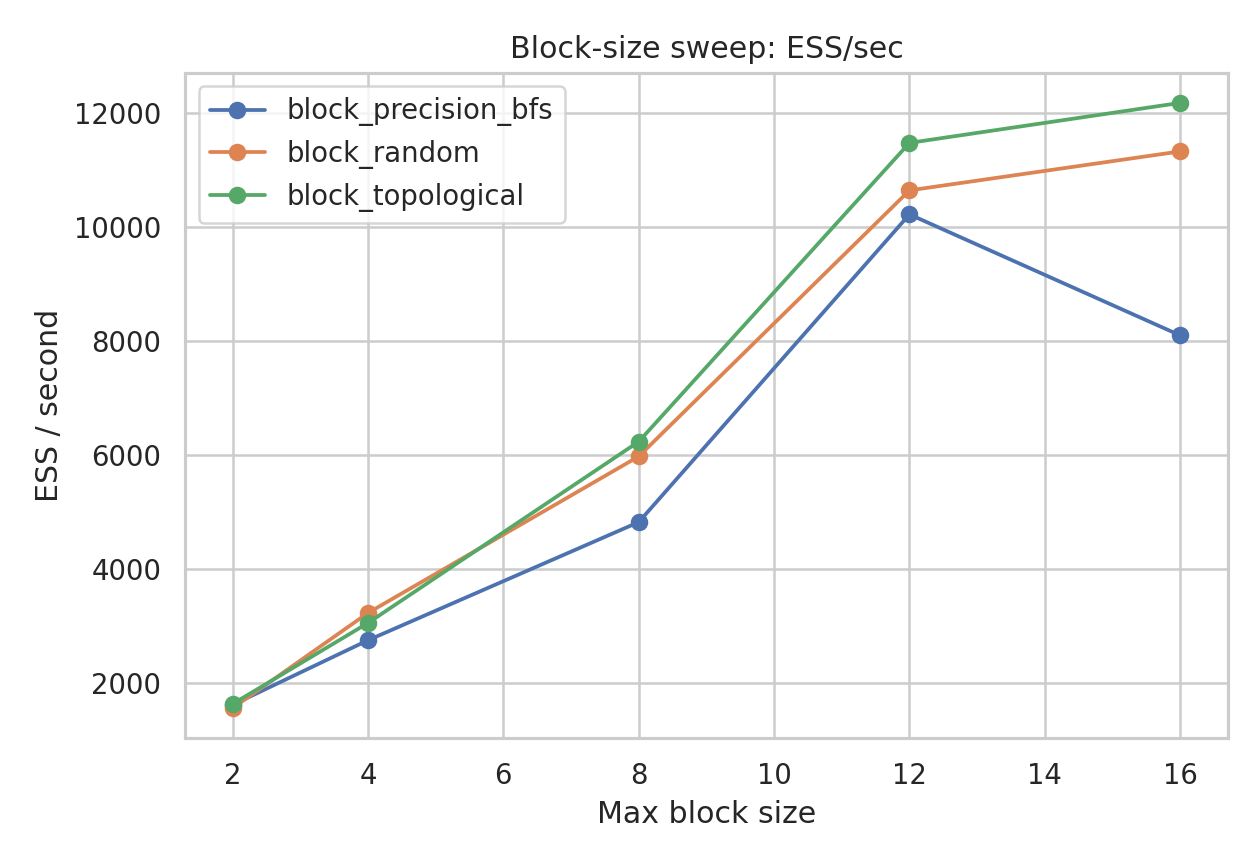

### block_sweep_mean_rmse.png

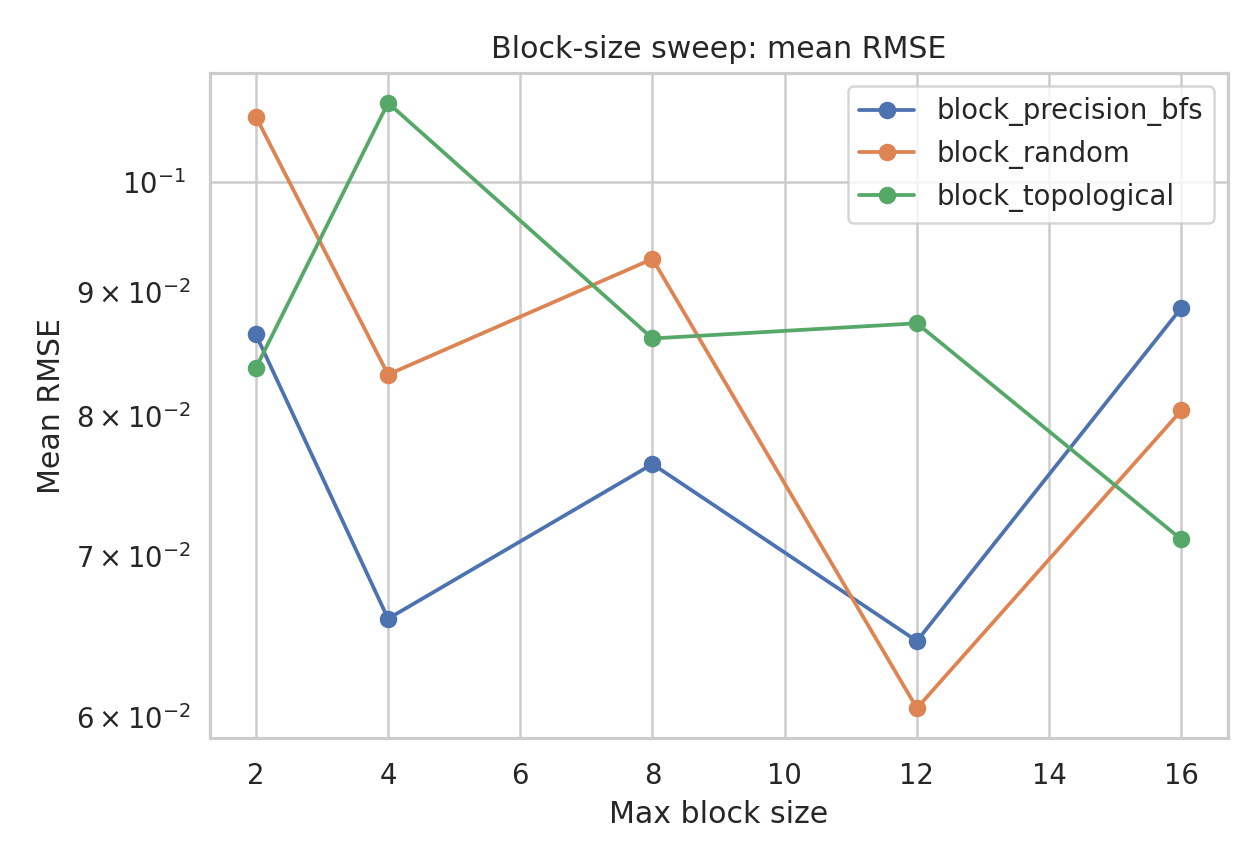

In [9]:

for fname in [
    "block_sweep_ess_per_second.png",
    "block_sweep_mean_rmse.png",
]:
    display(Markdown(f"### {fname}"))
    display(Image(filename=str(fig_dir / fname)))



## Interpretation of the block-size sweep

The block-size sweep clarifies an important tradeoff:

- larger blocks usually increase the **within-block precision mass**,
- that can reduce the **Gibbs spectral radius**,
- but larger blocks also increase per-iteration linear-algebra cost.

In the run included here:
- **topological blocks** were the best in raw ESS/sec at the largest tested block size,
- **precision-BFS blocks** had the strongest statistical quality for a given block size,
- the best block size was **not** the smallest one, so “more blocking” really does help here.

This is useful because it turns blocking into a tunable design question rather than a binary choice.



## Bottom line

The enhanced project now supports the following message:

1. **Prior DAG simulation is easy; posterior inference is not.**
2. **Naive DAG-native SIS can fail badly under hard evidence.**
3. **Single-site Gibbs is reliable, but block Gibbs can be better.**
4. **Block quality matters**: the blocks should align with the posterior precision structure.
5. **The Gaussian Gibbs spectral radius is a meaningful diagnostic** of posterior sampling difficulty.
6. **Rao-Blackwellization gives a clean variance-reduction improvement.**

That is a much stronger project than a shallow sampler benchmark.



## Reproducibility note

The bundle includes:
- this notebook,
- the enhanced pipeline code,
- the precomputed CSV results,
- the figures used in the notebook,
- an HTML export of the notebook for quick viewing.

You can rerun experiments directly from the CSV-producing functions in `enhanced_pipeline.py`.
